This notebook builds a portfolio construction workflow from transformed stock features and model predictions.

It trains a linear model to forecast next-month returns, converts the predictions into Black-Litterman views, combines them with the prior market equilibrium, and then solves a constrained Markowitz optimization problem to obtain portfolio weights.

In [6]:
#imports
import os
import sys
sys.path.append(os.path.abspath(".."))
from src.data.data_loader import DataLoad
from sklearn.linear_model import LinearRegression
import numpy as np
from scipy.stats import norm, spearmanr
import matplotlib.pyplot as plt
import cvxpy as cp



In [7]:
# im going to do this experiments with lin reg for simplicity


dl = DataLoad()
df = dl.load_dataset("backtest")
features = [c for c in df.columns if c not in ["Ticker","Target"]]
model = LinearRegression(n_jobs=-1)

backtest.csv loaded succesfully


In [8]:
# train model on train data and then build portfolio with test data

model.fit(df[df.index <= "2015-12-31"][features].to_numpy(), df[df.index <= "2015-12-31"]["Target"].to_numpy())

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",-1
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [9]:
# predict z scores of next month log returns, since these can be unstable, very high variance
# rank the predicted log returns, 1-30
# transform the ranks into a probability distribution across the 30 stock predictions
# use this probability distribution to compute z scores and pass z scores as "opinions"
# for black litterman optim
# this way any drift or any highly varied predictions don't affect our portfolio construction

X = df[df.index == "2016-01-29"]

preds = model.predict(X[features].to_numpy())
results = X[["Ticker"]].copy()
results["Predictions"] = preds
results["Ranking"] = results["Predictions"].rank(ascending=True) 
results["Probabilities"] = (results["Ranking"] - 0.5) / len(results["Ranking"])
results["Z-Score"] = norm.ppf(results["Probabilities"])
results = results.set_index("Ticker")
results

,Predictions,Ranking,Probabilities,Z-Score
Ticker,,,,
MSFT,0.058920,16.0,0.516667,0.041789
VZ,0.168213,23.0,0.750000,0.674490
LIN,-0.414631,3.0,0.083333,-1.382994
MS,-0.118554,10.0,0.316667,-0.477040
BAC,-0.287056,6.0,0.183333,-0.902735
NVDA,0.527754,30.0,0.983333,2.128045
JNJ,0.037715,14.0,0.450000,-0.125661
AVGO,0.282800,26.0,0.850000,1.036433
ORCL,-0.026314,12.0,0.383333,-0.296738


In [10]:
# for the confidence matrix we use rolling IC of past 6 months of predictions
# since we retrain every models every month, this would mean using test data
# this could lead to overconfident confidence matrix
# so we go saving predictions the model makes in a 6 month buffer, even if it has been retrained or redone hpt
# were seeing how confident we can be in the method, not this specific model
# then we have a more fair prediction for the IC that we use for the confidence matrix

# now simulate these last 6 months
# so act as if model has been trained until "2015-12-31", predicted 01/2016, trained on 01/2016, predicted 02/2016
# etc until predicted 06/2016, use those 6 months for IC and then predict 07/2026 amd build portfolio

X = df[(df.index > "2015-12-31") & (df.index <= "2016-06-30")]
months = X.index.unique().to_numpy()

y_preds = []
y_trues = []
for month in months:
    model.fit(df[df.index < month][features].to_numpy(), df[df.index < month]["Target"].to_numpy())
    y_preds.append(model.predict(df[df.index == month][features].to_numpy()))
    y_trues.append(df[df.index == month]["Target"].to_numpy())

ics = [spearmanr(y_pred,y_true)[0] for y_pred,y_true in zip(y_preds,y_trues)]
p_values = [spearmanr(y_pred,y_true)[1] for y_pred,y_true in zip(y_preds,y_trues)]

ics_adj = [ic * max(0, 1 - p_value) for ic,p_value in zip(ics,p_values) ] # soft shrinkage, helps reduce noisy signals smoothly
# a high p value means ic is not statistically significant from 0, but doeesnt mean its not financially significant, hence soft shrinkage

mean_ic = np.mean(ics_adj)
std_ic = np.std(ics_adj)

confidence_factor = mean_ic / std_ic

preds = model.predict(df[df.index == "2016-07-29"][features].to_numpy())
results = df.loc["2016-01-29", ["Ticker"]].copy()
results["Predictions"] = preds
results["Ranking"] = results["Predictions"].rank(ascending=True) 
results["Probabilities"] = (results["Ranking"] - 0.5) / len(results["Ranking"])
results["Z-Score"] = norm.ppf(results["Probabilities"])
results = results.set_index("Ticker")
results


,Predictions,Ranking,Probabilities,Z-Score
Ticker,,,,
MSFT,0.323372,28.0,0.916667,1.382994
VZ,-0.101810,9.0,0.283333,-0.572968
LIN,-0.138781,7.0,0.216667,-0.783500
MS,0.339797,30.0,0.983333,2.128045
BAC,-0.186696,4.0,0.116667,-1.191816
NVDA,0.038066,19.0,0.616667,0.296738
JNJ,-0.455889,1.0,0.016667,-2.128045
AVGO,-0.110826,8.0,0.250000,-0.674490
ORCL,-0.054423,14.0,0.450000,-0.125661


In [11]:
# okay now calculate covariance matrix
# will use daily data and 2 year lookback period

df_cov = dl.load_dataset("returns")

returns.csv loaded succesfully


In [12]:
# just predicted 2016-07-29
# cov matrix is built using last 2 years of daily data

df_cov = df_cov[df_cov.index <= "2016-07-29"].tail(504)
df_cov

,AAPL,AMZN,AVGO,BA,BAC,CAT,CMCSA,CVX,GOOG,GS,...,NKE,NVDA,ORCL,PFE,SHW,SLB,UNH,UPS,VZ,XOM
Date,,,,,,,,,,,,,,,,,,,,,
2014-07-31,-0.025981,-0.029518,-0.016026,-0.014801,-0.021181,-0.025440,-0.030319,-0.024824,-0.026931,-0.016443,...,-0.031152,-0.032080,-0.013916,-0.019139,-0.018700,-0.017049,-0.022905,-0.022748,-0.025889,-0.041744
2014-08-01,0.005544,-0.018946,0.015278,-0.000830,-0.017705,-0.002283,-0.006328,-0.010368,-0.009675,-0.015155,...,-0.004537,0.010857,-0.019311,0.005575,-0.007128,-0.004059,0.005429,-0.000618,-0.011702,-0.001414
2014-08-04,-0.005618,0.021462,0.012777,-0.003738,0.004673,0.012834,0.008616,0.002111,0.012507,0.008458,...,0.004949,-0.002261,0.012370,-0.003812,0.017679,0.015933,0.009571,0.001546,0.007626,0.013461
2014-08-05,-0.004917,-0.004240,-0.017101,0.011173,-0.003322,-0.003045,-0.012442,-0.025045,-0.014098,-0.013221,...,-0.003110,0.000567,-0.003491,-0.011826,-0.016125,-0.023616,-0.015559,-0.006894,-0.010954,-0.019275
2014-08-06,-0.001682,0.005027,0.002425,-0.018251,0.013333,-0.000098,-0.005265,0.006162,0.002308,0.001889,...,0.002860,-0.001133,0.005005,-0.004576,0.011609,0.004576,0.006297,-0.008082,-0.010673,0.007943
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2016-07-25,-0.013379,-0.007048,0.000689,-0.003971,-0.000696,-0.008692,0.000148,-0.024513,-0.003999,0.000623,...,0.007227,0.018474,0.001948,0.001089,0.005484,-0.011028,-0.013641,-0.002356,-0.004100,-0.019253
2016-07-26,-0.006883,-0.005435,0.022907,0.014367,0.011134,0.051595,-0.004298,-0.003784,-0.001825,0.004050,...,-0.013476,0.017062,-0.005345,0.001359,-0.007758,-0.001363,-0.000211,0.002453,-0.018973,-0.007267
2016-07-27,0.064963,0.001468,0.013583,0.008231,0.006882,0.016314,0.011015,-0.004090,0.004537,-0.001055,...,-0.010289,-0.010065,-0.000244,0.000543,-0.002048,-0.008933,-0.000142,-0.014225,0.009305,-0.006774


In [13]:
print(len(df_cov.columns))
print(df_cov.shape[0])

30
504


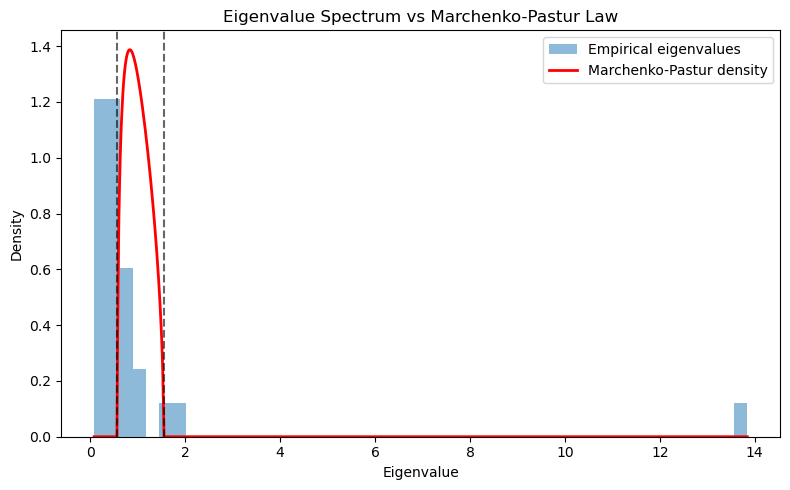

In [14]:
# calculate corr matrix and eigenvalues and cleaned cov matrix

vols = df_cov.std().values
D = np.diag(vols)

corr_matrix = df_cov.corr()
eigenvalues, eigenvectors = np.linalg.eigh(corr_matrix)

N = len(df_cov.columns)
T = df_cov.shape[0]

a = (1 - np.sqrt(N/T))**2
b = (1 + np.sqrt(N/T))**2
x = np.linspace(eigenvalues.min(), eigenvalues.max(), 1000)
density = np.zeros_like(x)
mask = (x >= a) & (x <= b)

density[mask] = (np.sqrt((b - x[mask]) * (x[mask] - a)) / (2 * np.pi * (N/T) * x[mask]))
mp = density

plt.figure(figsize=(8, 5))
plt.hist(eigenvalues, bins=50, density=True, alpha=0.5, label="Empirical eigenvalues")
plt.plot(x, mp, 'r', lw=2, label="Marchenko-Pastur density")
plt.axvline(a, color='k', linestyle='--', alpha=0.6)
plt.axvline(b, color='k', linestyle='--', alpha=0.6)
plt.title("Eigenvalue Spectrum vs Marchenko-Pastur Law")
plt.xlabel("Eigenvalue")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()

# since marchenko pastur law for cleaning is done on corr matrix
# var is assumed to be 1, so max eigen value that is noise is (1 + n/t) ^2
max_eigen = (1 + np.sqrt(N / T)) ** 2

noise_eigen = eigenvalues <= max_eigen
cleaned_eigenvalues = eigenvalues.copy()
cleaned_eigenvalues[noise_eigen] = np.mean(eigenvalues[noise_eigen])

clean_corr_matrix = eigenvectors @ np.diag(cleaned_eigenvalues) @ eigenvectors.T

# we need diag of corr matrix to be all 1s (corr with itself is 1), so we need to slightly modify the diag
diag = np.diag(clean_corr_matrix)
clean_corr_matrix = clean_corr_matrix / np.sqrt(np.outer(diag,diag))
# diag of corr is back to being one

# to go from cor to cov matrix, we multiply by the vol (std) of returns of each stock
# we calulcated this with the D before
clean_cov_matrix = D @ clean_corr_matrix @ D

# cov matrix is calculated with daily returns, so needs to be converted to monthly covariance, approx 21 trading days
sigma = clean_cov_matrix * 21




In [15]:
# now the equilibrium returns is needed, black litterman optimisation starts by assuming the current market is in perfect equilibrium
# the equilibrium returns vector is the vector of returns the stocks should have so that any rational investor would buy as is currently
# neutral estimation of returns
# it acts as the "prior" in black litterman, almost like in bayesion stats

# usually a reference portfolio is used, or percentage of the market for each company is used as the weights
# and with this plus the CAPM (capital asses pricing model), which states that the market is already in optimal equilibrium
# so if we know the "weights" of the markets portfolio, we can figure out what the market is "expecting" as returns, and thats the prior

# we will use the snp500 weights for our universe, so if our 30 stocks add up to 60 percent of the snp500, then each stocks weight is divided by that 60%
# since the snp500 is a market cap weighted index, we can directly use market caps

market_caps = dl.load_dataset("market_caps", date="2016-07-29")
total_mcap = np.sum(market_caps.to_numpy())
market_weights = (market_caps.to_numpy().flatten() / total_mcap).reshape(30, 1)

# assume industry standard delta of 2.5, coefficient of risk aversion, calculated as the market returns - the risk free rate / annual variance
delta = 2.5

# equilibrium returns
pi = delta * sigma @ market_weights


In [16]:
# map z scores unto real returs, as the "visions" matrix needs to be expressed in real returns units not z scores
# z scores get multiplied by the volatility of that stock, that way my "visions" vector is simply expressing std deviations against the market equilibrium
# model is seeing how much above or below the equilibrium or the prior are the returns for this stock going to be

# first take daily vol and convert into monthly vol 
monthly_vols = vols * np.sqrt(21)

# put in same order as other data so that columns align
results = results.reindex(df_cov.columns, axis=0)

# now create visions vector Q
results["Q"] = results["Z-Score"] * monthly_vols 
results

,Predictions,Ranking,Probabilities,Z-Score,Q
AAPL,0.020895,18.0,0.583333,0.210428,0.015548
AMZN,-0.146477,6.0,0.183333,-0.902735,-0.084853
AVGO,-0.110826,8.0,0.250000,-0.674490,-0.073967
BA,0.331781,29.0,0.950000,1.644854,0.110832
BAC,-0.186696,4.0,0.116667,-1.191816,-0.097002
CAT,0.063081,22.0,0.716667,0.572968,0.043466
CMCSA,-0.004680,17.0,0.550000,0.125661,0.007153
CVX,0.254267,26.0,0.850000,1.036433,0.079230
GOOG,-0.043892,15.0,0.483333,-0.041789,-0.003100
GS,-0.162242,5.0,0.150000,-1.036433,-0.071262


In [17]:
# we now have our predictions turned into z scores, we have our rolling IC, we have cleaned monthly covariance matrix (Sigma)
# we have Pi matrix or equilibrium matrix and we have our visions vector Q

# the only thing missing is omega or the uncertainty matrix, says how confident we are in predictions made by models
# or whether to trust more in market equilibrium
# omega = diag(P*(tau*sigma)*PT) * ((1-cf)/cf)



# our models predict stock performance independently, not stock a will beat stock b so P is the identity matrix as our predictions have no correlations
P = np.eye(30)

# confidence multiplier based on the rolling 6 month IR -> ICIR
conf_mult = (1 - confidence_factor) / confidence_factor

# we want only the variance of each stock, so we take the diagonal of the covariance matrix
Omega = np.diag(np.diag(P @ sigma @ P.T) * conf_mult)

In [18]:
# now we have all parts to black litterman optim
# takes market equilibrium or prior and adjusts it towards where models are predicting, with an "agressiveness" factor depending on accuracy of models
# E[R] = pi (prior) + (tau * sigma) @ PT @ ((P@(tau*sigma)@pT) + omega)^-1 @ (Q -(P*pi))
# this final term: (Q - P*pi) is the diff between what models are predicting and what market equilibrium is pricing in as expected returns
# sees what new information are models predicting, if it predicts same movement as market equilibrium expects, no new information
# tau * cov * PT * (P*tau*cov*pT + omega)^-1 is the kalman gain, decides whether to place more weight on prior or on predictions
# tau scales down the cov matrix, which says we have moso thre confidence in past market risk and equilibrium then in future returns
# omega gives the confidence in our views or predictions for future returns
# the larger omega is, the more uncertain we are, so when we inverse it will be near 0, so the multiplication with the final term will be near 0
# we stay near equilibrium
# if omega is small, expected returns moves towards our predictions and away from equilibrium

# there is not set value or standard for tau, one paper, michaud 1998 set as a simple rule something like
# tau = approx 1 / t(data), so in this case 1/504, which is approx 0.002, but since we move into monthly preds, multiply by 21
# approx 0.042, but we wan't to have a bit more confidence in prior, want models to "have to really work to prove themselves"
tau = 0.025

tau_sigma = tau * sigma
deviation = results["Q"].to_numpy().reshape(-1,1) - (P @ pi)
kalman_gain = tau_sigma @ P.T @ np.linalg.inv(((P @ tau_sigma @ P.T) + Omega))
results["Expected Returns"] = pi + (kalman_gain @ deviation)

In [19]:
# move onto markowiitz optimisation with restrictions
# maximize: wT * E[R] - 1/2 * gamma * wT * sigma * w
# wt * E[R] is the expected return of the portfolio built
# wt * cov matrix(sigma) * w is the variance or risk of the portfolio built
# this is multiplied by gamma, which is the aversion to risk
# the 1/2 is just for derivatives, makes it simpler

# in order to stabilize the weights, eg. not 100% of portfolio on the best performer, restrictions are added
# fully invested, so sum of abs(w) is 2, 100% on longs 100% on shorts
# academic setting so we assume risk and interest free borrowing etc.
# market neutral portfolio, so sum of w is 0
# concentration limits, no stock can occupy more then 10%, a equi balanced portfolio would be 1/30, 3.33%, so we allow a max of 3x weight onto one stock
# gamma is 2.5, we keep it the same as in equilibrium calculation, consisten investor pyschology

mu = results["Expected Returns"].to_numpy()
gamma = 2.5
n_assets = len(mu)

weights = cp.Variable(n_assets)
risk = cp.quad_form(weights,sigma)
returns = mu @ weights

objective = cp.Maximize(returns - ((1/2) * gamma * risk))
constraints = [weights >= -0.1, weights <= 0.1, cp.sum(weights) == 0, cp.norm1(weights) <= 2] # not equal to 2 as that would break optimizer
problem = cp.Problem(objective, constraints)
problem.solve(solver=cp.ECOS)



results["Portfolio Weights"] = weights.value
for ticker, value in zip(results.index, results["Portfolio Weights"]):
    print(f"{ticker}: {value}")


AAPL: 0.09999999986335087
AMZN: 0.05524759427080327
AVGO: 0.06510978111399024
BA: 0.08943085122014481
BAC: 0.05210151606478232
CAT: 0.02309233513331935
CMCSA: -0.06265899871078327
CVX: 0.07188839882694373
GOOG: 0.09053170289973585
GS: 0.0071967947598911685
HD: 0.005021556826073368
JNJ: -0.09999999996256877
JPM: 0.099999999409412
LIN: -0.09999999993272443
MCD: -0.09999999992222877
MMM: -0.09999999988793837
MRK: -0.031722800934926174
MS: 0.09999999996062585
MSFT: 0.09999999995081965
NEE: -0.09999999997301585
NKE: 0.0178197508007868
NVDA: 0.06308405871674336
ORCL: -0.0004612586243977186
PFE: -0.09999999993345142
SHW: -0.03206240108322249
SLB: 0.01384312194827897
UNH: 0.03146835695037274
UPS: -0.09999999991664417
VZ: -0.09999999995473886
XOM: -0.05893035987943314


## Complete Summary of Portfolio Construction

This notebook turns model forecasts into an investable long-short portfolio by combining expected returns, covariance information, and portfolio constraints.

### Workflow Summary

- A model is trained on the transformed feature dataset.
- Next-month stock predictions are ranked and converted into probability-based Z-scores.
- Those scores are used as Black-Litterman views to update the prior equilibrium returns.
- A constrained Markowitz optimization is solved to produce the final portfolio weights.

### Main Outcome

The final result is a market-neutral, weight-limited portfolio that blends statistical forecasts with covariance-aware allocation.

---